# Runoff Forecasting Project - Group 9

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin  
**Course:** Artificial Intelligence, Appalachian State University  
**GitHub:** https://github.com/zachshotwell/AI-FinalProject-GroupSCR

**Dataset:** NOAA National Water Model (NWM) short-range streamflow forecasts paired with USGS observed streamflow for two stations from April 2021 through April 2023.  
**Task:** Predict forecast residual error, `USGS_obs - NWM_forecast`, for lead times 1–18 hours, then reconstruct corrected runoff forecasts — a multistep regression problem.  
**Approach:** After aligning NWM and USGS data on an hourly grid, we build per-station sequence datasets, compare recurrent neural-network post-processors against the raw NWM/persistence baseline, and evaluate corrected forecasts with per-lead-time hydrologic metrics.

## Setup

In [1]:
!git clone https://github.com/zachshotwell/AI-FinalProject-GroupSCR
%cd AI-FinalProject-GroupSCR
%cd RunoffForecastingProject
!ls

Cloning into 'AI-FinalProject-GroupSCR'...
remote: Enumerating objects: 2204, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 2204 (delta 75), reused 5 (delta 2), pack-reused 2071 (from 2)
Receiving objects: 100% (2204/2204), 65.27 MiB | 26.64 MiB/s, done.
Resolving deltas: 100% (1734/1734), done.
/content/AI-FinalProject-GroupSCR
/content/AI-FinalProject-GroupSCR/RunoffForecastingProject
 data
'Improved runoff forecasting performance through error predictions using a deep-learning approach.pdf'
 README.md
 RunoffForcastingProject.pdf
 RunoffForecasting.ipynb


In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import json

tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Reconnaissance

Before building the loader, we inspect one USGS observation file and one monthly
NWM forecast file from each station folder to confirm the raw schema and time layout.

This check is used to verify:
- forecast layout (long vs. wide)
- column names and dtypes
- datetime fields and time coverage
- sampling cadence
- rough streamflow magnitude and likely units

This section is exploratory only; final cleaning, alignment, and unit handling are done in the loader section.

In [3]:
DATA_ROOT = Path("data")

# folder names are NWM reach IDs (NHDPlus COMIDs); paired USGS gauges:
stations = {
    "20380357": "09520500",
    "21609641": "11266500",
}

for nwm_id, usgs_id in stations.items():
    folder = DATA_ROOT / nwm_id
    print("\n" + "=" * 72)
    print(f"{folder}   (paired USGS gauge: {usgs_id})")
    print("=" * 72)

    csvs = sorted(folder.glob("*.csv"))
    usgs_file = next(f for f in csvs if "Strt" in f.name and "EndAt" in f.name)
    nwm_files = [f for f in csvs if f.name.startswith("streamflow_")]

    print(f"USGS file: {usgs_file.name}")
    print(f"NWM files: {len(nwm_files)}  (first: {nwm_files[0].name}, last: {nwm_files[-1].name})")

    print(f"\n--- USGS {usgs_id} ---")
    usgs_df = pd.read_csv(usgs_file)
    usgs_df.info()
    print(usgs_df.head(3))
    print("...")
    print(usgs_df.tail(3))

    print(f"\n--- NWM forecast (sample: {nwm_files[0].name}) ---")
    nwm_df = pd.read_csv(nwm_files[0])
    print(f"shape: {nwm_df.shape}  ->  {'LONG' if nwm_df.shape[1] <= 5 else 'WIDE'} format")
    print(nwm_df.head(3))

    # parse datetime columns to confirm coverage
    for col in [c for c in nwm_df.columns if "time" in c.lower()]:
        fmt = "%Y-%m-%d_%H:%M:%S" if "model_" in col else None
        t = pd.to_datetime(nwm_df[col], format=fmt, utc=True)
        print(f"  {col}: {t.min()} -> {t.max()}  ({t.nunique()} unique)")

    # quick unit check
    q_max = nwm_df["streamflow_value"].max()
    print(f"  streamflow_value max = {q_max:.2f}  ->  likely {'cfs' if q_max > 1000 else 'cms'}")


data/20380357   (paired USGS gauge: 09520500)
USGS file: 09520500_Strt_2021-04-20_EndAt_2023-04-21.csv
NWM files: 25  (first: streamflow_20380357_202104.csv, last: streamflow_20380357_202304.csv)

--- USGS 09520500 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70089 entries, 0 to 70088
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DateTime       70089 non-null  object 
 1   USGSFlowValue  70089 non-null  float64
 2   USGS_GageID    70089 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.6+ MB
                    DateTime  USGSFlowValue USGS_GageID
0  2021-04-20 07:00:00+00:00           0.18           A
1  2021-04-20 07:15:00+00:00           0.18           A
2  2021-04-20 07:30:00+00:00           0.19           A
...
                        DateTime  USGSFlowValue USGS_GageID
70086  2023-04-22 06:15:00+00:00           0.15           A
70087  2023-04-22 06:30:00+00:00           0.15     

## Data Preparation

This section converts the raw NWM forecast files and USGS observations into a
single tidy hourly table for each station. The main steps are:
- parse NWM issue times and valid times
- resample USGS observations from 15-minute to hourly cadence
- align NWM forecasts with USGS observations on `valid_time`
- compute forecast residuals as `error = usgs_q - nwm_q`

The resulting tidy tables are saved for downstream splitting, windowing, model
training, and evaluation.

In [4]:
NWM_DT_FMT = "%Y-%m-%d_%H:%M:%S"  # underscore separator; explicit format avoids the slow dateutil fallback

def load_usgs_hourly(usgs_file):
    df = pd.read_csv(usgs_file)
    df["DateTime"] = pd.to_datetime(df["DateTime"], utc=True)
    s = df.set_index("DateTime")["USGSFlowValue"].sort_index()
    return s.asfreq("h").rename("usgs_q")  # instantaneous values, not aggregated

def load_nwm_station(folder):
    parts = []
    for f in sorted(folder.glob("streamflow_*.csv")):
        df = pd.read_csv(f)
        df["init_time"]  = pd.to_datetime(df["model_initialization_time"], format=NWM_DT_FMT, utc=True)
        df["valid_time"] = pd.to_datetime(df["model_output_valid_time"],   format=NWM_DT_FMT, utc=True)
        df["lead_h"] = ((df["valid_time"] - df["init_time"]).dt.total_seconds() // 3600).astype(int)
        df = df.rename(columns={"streamflow_value": "nwm_q"})
        parts.append(df[["init_time", "valid_time", "lead_h", "nwm_q"]])
    nwm = pd.concat(parts, ignore_index=True)
    return (nwm.drop_duplicates(["init_time", "lead_h"])
               .sort_values(["init_time", "lead_h"])
               .reset_index(drop=True))

for nwm_id, usgs_id in stations.items():
    folder = DATA_ROOT / nwm_id
    csvs = sorted(folder.glob("*.csv"))
    nwm_files = [f for f in csvs if f.name.startswith("streamflow_")]
    usgs_file = [f for f in csvs if f not in nwm_files][0]

    usgs = load_usgs_hourly(usgs_file)
    nwm = load_nwm_station(folder)

    df = nwm.merge(usgs, left_on="valid_time", right_index=True, how="left")
    df["error"] = df["usgs_q"] - df["nwm_q"]
    df = df[["valid_time", "init_time", "lead_h", "nwm_q", "usgs_q", "error"]]

    out = folder / f"tidy_{nwm_id}.parquet"
    df.to_parquet(out)

    print(f"\n=== Station {nwm_id} (USGS {usgs_id}) ===")
    print(f"rows: {len(df):,}   inits: {df['init_time'].nunique():,}   leads: {df['lead_h'].min()}..{df['lead_h'].max()}")
    print(f"valid_time: {df['valid_time'].min()} -> {df['valid_time'].max()}")
    print(f"missing usgs_q: {df['usgs_q'].isna().sum():,} ({df['usgs_q'].isna().mean():.1%})")

    lead1 = df[df["lead_h"] == 1].dropna()
    print(f"lead_h=1 (n={len(lead1):,}): nwm med={lead1['nwm_q'].median():.3f}  usgs med={lead1['usgs_q'].median():.3f}  error mean={lead1['error'].mean():+.3f}")
    print(f"wrote: {out}")


=== Station 20380357 (USGS 09520500) ===
rows: 315,789   inits: 17,544   leads: 1..18
valid_time: 2021-04-21 01:00:00+00:00 -> 2023-04-22 17:00:00+00:00
missing usgs_q: 1,164 (0.4%)
lead_h=1 (n=17,483): nwm med=3.930  usgs med=0.240  error mean=-4.840
wrote: data/20380357/tidy_20380357.parquet

=== Station 21609641 (USGS 11266500) ===
rows: 315,789   inits: 17,544   leads: 1..18
valid_time: 2021-04-21 01:00:00+00:00 -> 2023-04-22 17:00:00+00:00
missing usgs_q: 18,372 (5.8%)
lead_h=1 (n=16,527): nwm med=6.300  usgs med=7.080  error mean=+0.282
wrote: data/21609641/tidy_21609641.parquet


## Exploratory Data Analysis

This section visualizes the hourly lead-1 series for each station after alignment.
The goals are to:
- compare raw NWM forecasts against USGS observations
- inspect the residual series `error = usgs_q - nwm_q`
- summarize missing observations before imputation
- examine residual autocorrelation to assess whether a short input window such as `L = 6` is reasonable

Train, validation, and test periods are shaded to make the chronological split visible.

Missing-data summary (raw, before forward-fill):
  20380357: 61 / 17,544 hours missing USGS (0.3%)
  21609641: 1,017 / 17,544 hours missing USGS (5.8%)


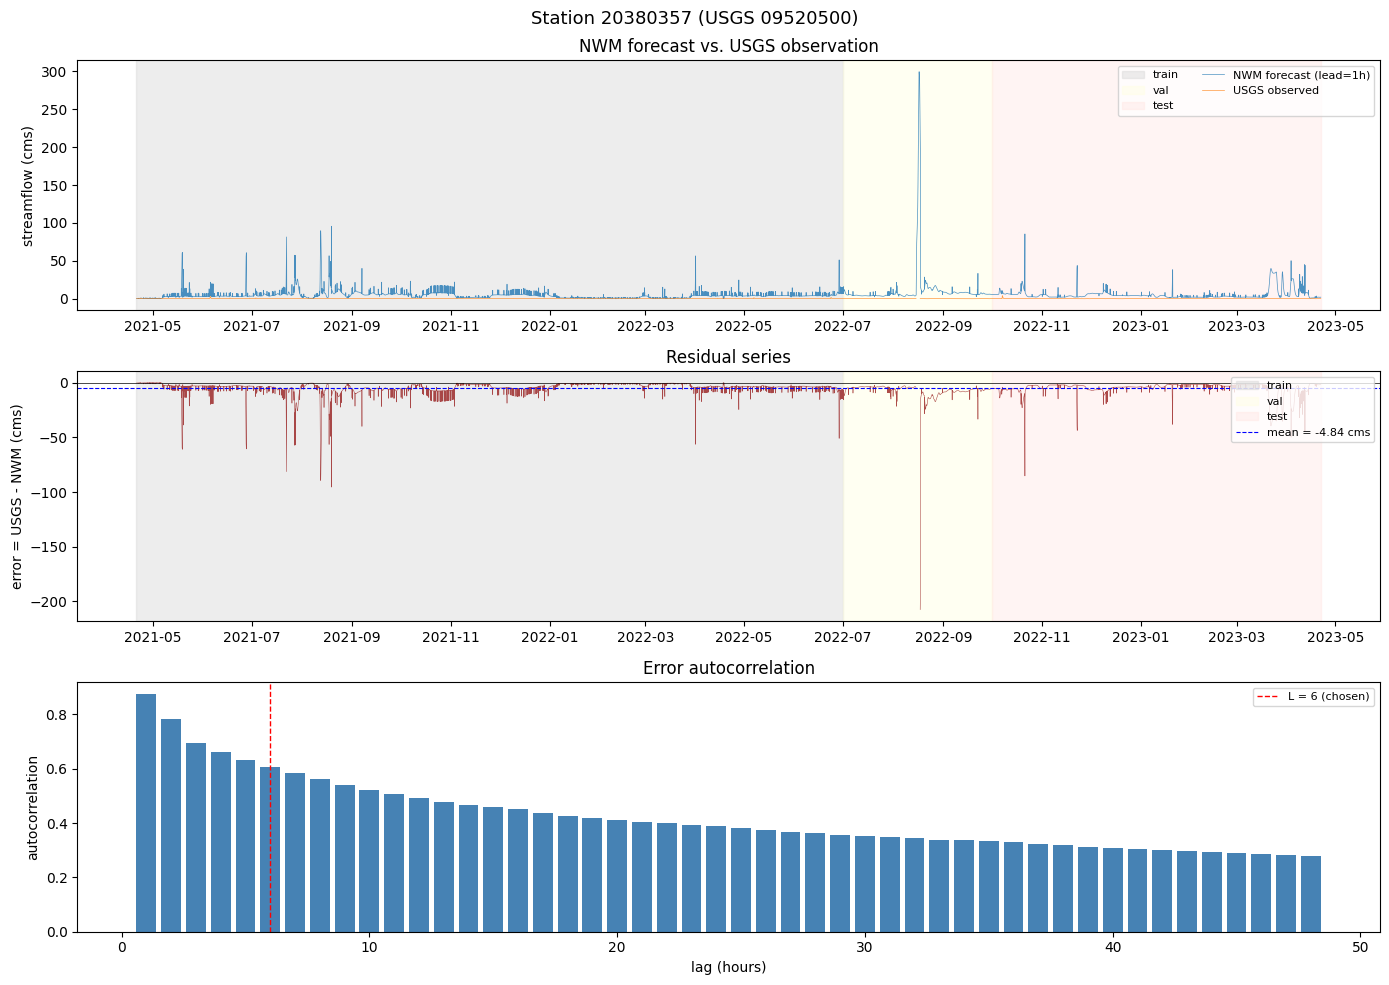

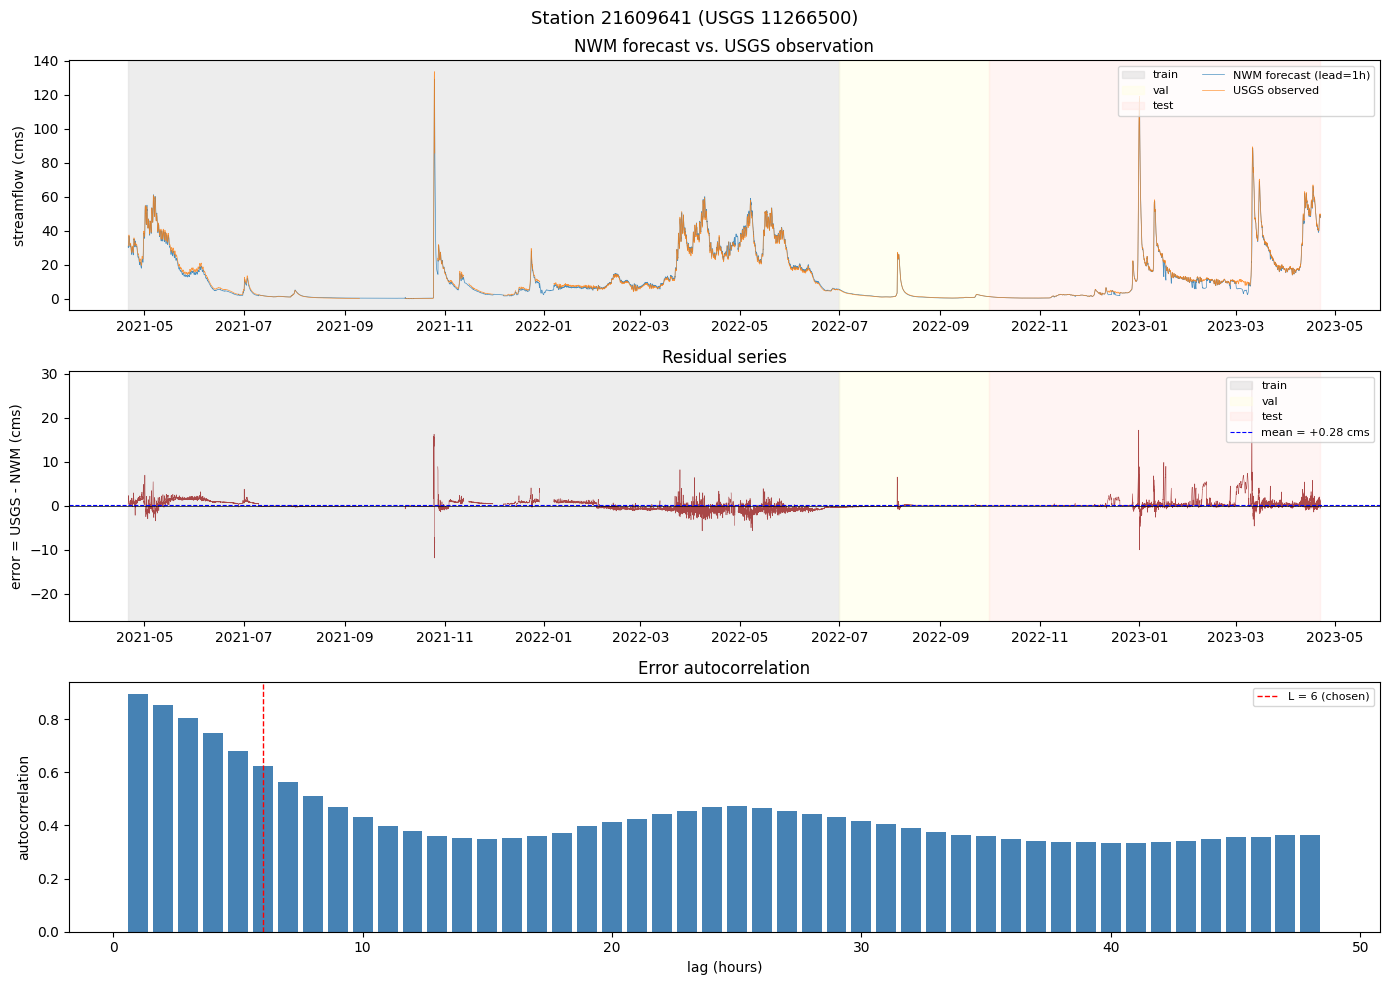

In [5]:
def load_tidy(station_id):
    df = pd.read_parquet(DATA_ROOT / station_id / f"tidy_{station_id}.parquet")
    df = df[df["lead_h"] == 1].set_index("valid_time").sort_index()
    return df[["nwm_q", "usgs_q", "error"]]

SPLITS = [
    ("2021-04-21", "2022-07-01", "lightgray",   "train"),
    ("2022-07-01", "2022-10-01", "lightyellow", "val"),
    ("2022-10-01", "2023-04-22", "mistyrose",   "test"),
]

def shade_splits(ax):
    for start, end, color, label in SPLITS:
        ax.axvspan(pd.Timestamp(start, tz="UTC"), pd.Timestamp(end, tz="UTC"),
                   alpha=0.4, color=color, label=label)

def plot_station(df, station_id, usgs_id):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f"Station {station_id} (USGS {usgs_id})", fontsize=13)

    ax = axes[0]
    shade_splits(ax)
    ax.plot(df.index, df["nwm_q"],  lw=0.5, alpha=0.8, label="NWM forecast (lead=1h)")
    ax.plot(df.index, df["usgs_q"], lw=0.5, alpha=0.8, label="USGS observed")
    ax.set_ylabel("streamflow (cms)")
    ax.set_title("NWM forecast vs. USGS observation")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    ax = axes[1]
    shade_splits(ax)
    ax.plot(df.index, df["error"], lw=0.4, color="darkred", alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(df["error"].mean(), color="blue", lw=0.8, ls="--",
               label=f"mean = {df['error'].mean():+.2f} cms")
    ax.set_ylabel("error = USGS - NWM (cms)")
    ax.set_title("Residual series")
    ax.legend(loc="upper right", fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    ax = axes[2]
    err = df["error"].dropna().values
    err = err - err.mean()
    var = (err ** 2).mean()
    lags = np.arange(1, 49)
    acf = np.array([(err[:-k] * err[k:]).mean() / var for k in lags])
    ax.bar(lags, acf, width=0.8, color="steelblue")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(6, color="red", lw=1, ls="--", label="L = 6 (chosen)")
    ax.set_xlabel("lag (hours)")
    ax.set_ylabel("autocorrelation")
    ax.set_title("Error autocorrelation")
    ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

print("Missing-data summary (raw, before forward-fill):")
for sid in stations:
    df = load_tidy(sid)
    n, n_missing = len(df), df["usgs_q"].isna().sum()
    print(f"  {sid}: {n_missing:,} / {n:,} hours missing USGS ({n_missing/n:.1%})")

for sid, usgs_id in stations.items():
    plot_station(load_tidy(sid), sid, usgs_id)

## Chronological Train/Validation/Test Split

To prevent temporal leakage, each station’s tidy hourly table is split
chronologically using `valid_time` as the index.

Following the project specification:
- training and validation use April 2021 through September 2022
- testing uses October 2022 through April 2023

The validation set is taken from the most recent portion of the pre-test period,
which follows the common time-series convention of validating on the latest
available training-era data.

In [6]:
TRAIN_RANGE = ("2021-04", "2022-06")
VALID_RANGE = ("2022-07", "2022-09")
TEST_RANGE  = ("2022-10", "2023-04")

def split_station(sid):
    df = pd.read_parquet(DATA_ROOT / sid / f"tidy_{sid}.parquet")
    df = df.set_index("valid_time").sort_index()
    return (df.loc[TRAIN_RANGE[0]:TRAIN_RANGE[1]],
            df.loc[VALID_RANGE[0]:VALID_RANGE[1]],
            df.loc[TEST_RANGE[0]:TEST_RANGE[1]])

def report(name, df):
    n_days = df.index.normalize().nunique()
    print(f"  {name:6s}: {len(df):>7,} rows | {df.index.min()} -> {df.index.max()} | {n_days} unique days")

for sid in stations:
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")
    train, valid, test = split_station(sid)
    for name, part in [("train", train), ("valid", valid), ("test", test)]:
        report(name, part)
        part.reset_index().to_parquet(DATA_ROOT / sid / f"{name}_{sid}.parquet")
    print(f"  wrote: train_/valid_/test_{sid}.parquet")


station 20380357
  train : 188,181 rows | 2021-04-21 01:00:00+00:00 -> 2022-06-30 23:00:00+00:00 | 436 unique days
  valid :  39,744 rows | 2022-07-01 00:00:00+00:00 -> 2022-09-30 23:00:00+00:00 | 92 unique days
  test  :  87,864 rows | 2022-10-01 00:00:00+00:00 -> 2023-04-22 17:00:00+00:00 | 204 unique days
  wrote: train_/valid_/test_20380357.parquet

station 21609641
  train : 188,181 rows | 2021-04-21 01:00:00+00:00 -> 2022-06-30 23:00:00+00:00 | 436 unique days
  valid :  39,744 rows | 2022-07-01 00:00:00+00:00 -> 2022-09-30 23:00:00+00:00 | 92 unique days
  test  :  87,864 rows | 2022-10-01 00:00:00+00:00 -> 2023-04-22 17:00:00+00:00 | 204 unique days
  wrote: train_/valid_/test_21609641.parquet


## Sequencing Window and Dataset Construction

We construct sliding-window training samples from each split. The input window has length L=6 hours; the target horizon is H=18 hours; lead_h=1 rows are used (one row per valid_time) to give a clean per-hour series.

**Temporal layout (no leakage).** Input features at sample i are observed at times t−5 through t — the recent past, including residuals (`error`), NWM forecasts (`nwm_q`), and USGS observations (`usgs_q`). Targets at sample i are residuals at times t+1 through t+18 — the future. The model never sees future `usgs_q` or future `error`. Operationally this corresponds to: at forecast issue time, post-process using the most recent six hours of gauge observations and NWM forecast values.

**Note on lead-time semantics.** "Lead = h hours" in our results refers to the h-hours-ahead prediction horizon from the input window, *not* the NWM short-range forecast lead-time index. Our setup uses `lead_h=1` rows from the NWM throughout — i.e., for each future hour t+h we use the NWM forecast issued at t+h−1 valid for t+h. Whether to additionally vary the NWM lead-time used as input is identified as future work.

**Normalization.** Features are z-scored using train-set statistics only; targets are kept in raw cms so predictions are directly interpretable as flow corrections.

In [7]:
L = 6
H = 18
BATCH_SIZE = 128

FEATURE_COLS = ["error", "nwm_q", "usgs_q"]
TARGET_COL = "error"

def prepare_features(split_df):
    # collapse to one row per hour at lead_h=1; forward/back-fill USGS gaps
    df = split_df[split_df["lead_h"] == 1].set_index("valid_time").sort_index()
    return df[FEATURE_COLS].ffill().bfill()

def build_seq2seq_targets(series, L, H):
    # row i  ==  series[i+L : i+L+H]
    N = len(series)
    n_windows = N - L - H + 1
    out = np.empty((n_windows, H), dtype=np.float32)
    for h in range(H):
        out[:, h] = series[L + h : N - H + 1 + h]
    return out

datasets = {sid: {} for sid in stations}
norm_stats = {}

for sid in stations:
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")

    splits = {name: pd.read_parquet(DATA_ROOT / sid / f"{name}_{sid}.parquet")
              for name in ("train", "valid", "test")}
    feats = {name: prepare_features(df) for name, df in splits.items()}

    mean = feats["train"].mean().values
    std = feats["train"].std().replace(0.0, 1.0).values
    norm_stats[sid] = (mean, std)

    for name, df in feats.items():
        x = ((df.values - mean) / std).astype(np.float32)
        # targets stay in raw cms so predictions are directly in physical units
        y_series = df[TARGET_COL].values.astype(np.float32)
        targets = build_seq2seq_targets(y_series, L, H)
        datasets[sid][name] = tf.keras.utils.timeseries_dataset_from_array(
            data=x[:-H],
            targets=targets,
            sequence_length=L,
            batch_size=BATCH_SIZE,
            shuffle=(name == "train"),
            seed=42,
        )

    print(f"  L={L}  H={H}  batch={BATCH_SIZE}")
    print(f"  features={FEATURE_COLS}   target={TARGET_COL} (raw cms)")
    print(f"  train norm stats:")
    for col, m, s in zip(FEATURE_COLS, mean, std):
        print(f"    {col:8s}  mean={m:8.3f}   std={s:8.3f}")
    print(f"  dataset shapes:")
    for name, ds in datasets[sid].items():
        x_batch, y_batch = next(iter(ds))
        n_batches = sum(1 for _ in ds)
        print(f"    {name:6s}  batches={n_batches:>4}   x={tuple(x_batch.shape)}   y={tuple(y_batch.shape)}")


station 20380357
  L=6  H=18  batch=128
  features=['error', 'nwm_q', 'usgs_q']   target=error (raw cms)
  train norm stats:
    error     mean=  -4.183   std=   5.547
    nwm_q     mean=   4.452   std=   5.545
    usgs_q    mean=   0.270   std=   0.132
  dataset shapes:
    train   batches=  82   x=(128, 6, 3)   y=(128, 18)
    valid   batches=  18   x=(128, 6, 3)   y=(128, 18)
    test    batches=  38   x=(128, 6, 3)   y=(128, 18)

station 21609641
  L=6  H=18  batch=128
  features=['error', 'nwm_q', 'usgs_q']   target=error (raw cms)
  train norm stats:
    error     mean=   0.212   std=   1.513
    nwm_q     mean=  13.158   std=  14.573
    usgs_q    mean=  13.374   std=  14.441
  dataset shapes:
    train   batches=  82   x=(128, 6, 3)   y=(128, 18)
    valid   batches=  18   x=(128, 6, 3)   y=(128, 18)
    test    batches=  38   x=(128, 6, 3)   y=(128, 18)


## Baselines: Raw NWM and Persistence

Two non-trivial baselines are saved alongside the DL models so the eval cell can compare apples-to-apples:

- **Raw NWM** — the un-corrected NWM forecast, equivalent to `error_pred = 0`. Tells us whether the post-processor improves on the operational NWM forecast at all.
- **Persistence** — forecast at horizon h = the last observed USGS value at issue time, held flat for h ∈ 1..18. This is the textbook hydrologic baseline. A model that beats raw NWM but loses to persistence has only learned that observed values are autocorrelated, not anything specific about NWM bias structure.

In [14]:
# Two non-trivial baselines for the eval cell to consume:
#
#   raw_nwm:     forecast = NWM as-is, i.e. error_pred = 0.
#                Equivalent to "no post-processing applied."
#
#   persistence: forecast = last observed USGS value, held flat for h = 1..18.
#                Standard hydrologic baseline. Equivalent to error_pred =
#                (usgs_q[t] - nwm_q[t+h]) for each future hour h.
#
# Both are saved as preds_*.npy in the same shape DL models produce, so the
# eval cell can treat them identically.
for sid in stations:
    test_split = pd.read_parquet(DATA_ROOT / sid / f"test_{sid}.parquet")
    test_feats = prepare_features(test_split)

    nwm_grid = build_seq2seq_targets(test_feats["nwm_q"].values.astype(np.float32), L, H)
    usgs_series = test_feats["usgs_q"].values.astype(np.float32)
    n_windows = nwm_grid.shape[0]

    # raw_nwm: zero correction
    raw_nwm_preds = np.zeros((n_windows, H), dtype=np.float32)
    np.save(DATA_ROOT / sid / f"preds_raw_nwm_{sid}.npy", raw_nwm_preds)

    # persistence: forecast = last observed USGS at issue time t (i.e., index L-1
    # into each window), held flat across h = 1..18. Implied error correction is
    # (usgs_q[t] - nwm_q[t+h]) for each future hour h.
    last_obs = usgs_series[L - 1 : L - 1 + n_windows]               # (n_windows,)
    persistence_forecast = np.broadcast_to(last_obs[:, None], (n_windows, H))
    persistence_preds = (persistence_forecast - nwm_grid).astype(np.float32)
    np.save(DATA_ROOT / sid / f"preds_persistence_{sid}.npy", persistence_preds)

    print(f"  {sid}: saved preds_raw_nwm_{sid}.npy  shape={raw_nwm_preds.shape}")
    print(f"          saved preds_persistence_{sid}.npy  shape={persistence_preds.shape}")

  20380357: saved preds_raw_nwm_20380357.npy  shape=(4850, 18)
          saved preds_persistence_20380357.npy  shape=(4850, 18)
  21609641: saved preds_raw_nwm_21609641.npy  shape=(4850, 18)
          saved preds_persistence_21609641.npy  shape=(4850, 18)


## GRU, LSTM Simple, and Stacked LSTM

Three recurrent architectures are trained per station, all predicting the 18-hour residual error sequence directly via a Dense head:

- **GRU**: `GRU(32) → Dense(18)` — NB2 model zoo entry 5.
- **LSTM simple**: `LSTM(32) → Dense(18)` — NB2 entry 5 with an LSTM cell in place of the GRU.
- **Stacked LSTM**: `LSTM(32, return_sequences=True) → LSTM(32) → Dense(18)` — NB2 entry 3.

All three architectures use 32 recurrent units, following Han & Morrison's published sensitivity analysis. The architectures are deliberately shallow: with roughly 10,500 training windows, deeper networks tend to overfit.

Training configuration:

- Loss: Huber (robust to flood-peak outliers)
- Optimizer: Adam, learning rate `1e-3`, `clipnorm=1.0` (gradient clipping for RNN training stability)
- Metric: MAE (in raw `cms`, since targets are unnormalized)
- Callbacks: `EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True)` and `ReduceLROnPlateau(factor=0.5, patience=5)`
- `clear_session()` and `set_seed(42)` before each model build, per Géron NB2 convention

For each `(station, model)` pair, the trained model and its test-set predictions are saved alongside the persistence baseline so all forecasts can be compared through a single downstream evaluation pipeline.

In [9]:
EPOCHS = 200
UNITS = 32  # paper's optimum for both architectures

def build_gru(n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.GRU(UNITS),
        tf.keras.layers.Dense(H),
    ])

def build_lstm_simple(n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.LSTM(UNITS),
        tf.keras.layers.Dense(H),
    ])

def build_lstm_stacked(n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.LSTM(UNITS, return_sequences=True),
        tf.keras.layers.LSTM(UNITS),
        tf.keras.layers.Dense(H),
    ])

model_builders = {"gru": build_gru, "lstm_simple": build_lstm_simple, "lstm_stacked": build_lstm_stacked}

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs visible: {len(gpus)}")

n_features = len(FEATURE_COLS)
summary = {}

histories = {}
for sid in stations:
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")
    for model_name, build in model_builders.items():
        print(f"\n{'-'*70}\n  {sid}  /  {model_name}\n{'-'*70}")

        model = build(n_features)
        model.compile(
            loss=tf.keras.losses.Huber(),
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
            metrics=["mae"],
        )
        model.summary(line_length=70)

        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=5),
        ]

        history = model.fit(
            datasets[sid]["train"],
            validation_data=datasets[sid]["valid"],
            epochs=EPOCHS,
            callbacks=callbacks,
            verbose=2,
        )
        histories[(sid, model_name)] = history.history
        with open(DATA_ROOT / sid / f"hist_{model_name}_{sid}.json", "w") as f:
          json.dump(history.history, f)

        _, val_mae = model.evaluate(datasets[sid]["valid"], verbose=0)
        _, test_mae = model.evaluate(datasets[sid]["test"], verbose=0)

        model.save(DATA_ROOT / sid / f"{model_name}_{sid}.keras")
        preds = model.predict(datasets[sid]["test"], verbose=0)
        np.save(DATA_ROOT / sid / f"preds_{model_name}_{sid}.npy", preds)

        summary[(sid, model_name)] = (val_mae, test_mae)
        print(f"  val_mae:  {val_mae:.4f} cms")
        print(f"  test_mae: {test_mae:.4f} cms")

print(f"\n{'='*70}\nfinal MAE summary (cms, lower=better)\n{'='*70}")
print(f"  {'station':<12} {'model':<14} {'val_mae':>10} {'test_mae':>10}")
for (sid, name), (vm, tm) in summary.items():
    print(f"  {sid:<12} {name:<14} {vm:>10.4f} {tm:>10.4f}")

GPUs visible: 1

station 20380357

----------------------------------------------------------------------
  20380357  /  gru
----------------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ gru (GRU)                    │ (None, 32)            │       3,552 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 18)            │         594 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 4,146 (16.20 KB)

 Trainable params: 4,146 (16.20 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ lstm (LSTM)                  │ (None, 6, 32)         │       4,608 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ lstm_1 (LSTM)                │ (None, 32)            │       8,320 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 18)            │         594 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 13,522 (52.82 KB)

 Trainable params: 13,522 (52.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
82/82 - 4s - 48ms/step - loss: 0.3645 - mae: 0.6451 - val_loss: 0.0249 - val_mae: 0.1329 - learning_rate: 0.0010
Epoch 2/200
82/82 - 3s - 36ms/step - loss: 0.2518 - mae: 0.4381 - val_loss: 0.0211 - val_mae: 0.0887 - learning_rate: 0.0010
Epoch 3/200
82/82 - 2s - 23ms/step - loss: 0.2337 - mae: 0.4118 - val_loss: 0.0196 - val_mae: 0.0602 - learning_rate: 0.0010
Epoch 4/200
82/82 - 2s - 23ms/step - loss: 0.2229 - mae: 0.3966 - val_loss: 0.0205 - val_mae: 0.0553 - learning_rate: 0.0010
Epoch 5/200
82/82 - 2s - 23ms/step - loss: 0.2166 - mae: 0.3876 - val_loss: 0.0194 - val_mae: 0.0524 - learning_rate: 0.0010
Epoch 6/200
82/82 - 2s - 23ms/step - loss: 0.2118 - mae: 0.3820 - val_loss: 0.0194 - val_mae: 0.0569 - learning_rate: 0.0010
Epoch 7/200
82/82 - 2s - 24ms/step - loss: 0.2071 - mae: 0.3769 - val_loss: 0.0194 - val_mae: 0.0601 - learning_rate: 0.0010
Epoch 8/200
82/82 - 3s - 36ms/step - loss: 0.2031 - mae: 0.3712 - val_loss: 0.0185 - val_mae: 0.0563 - learning_rate: 0.0010


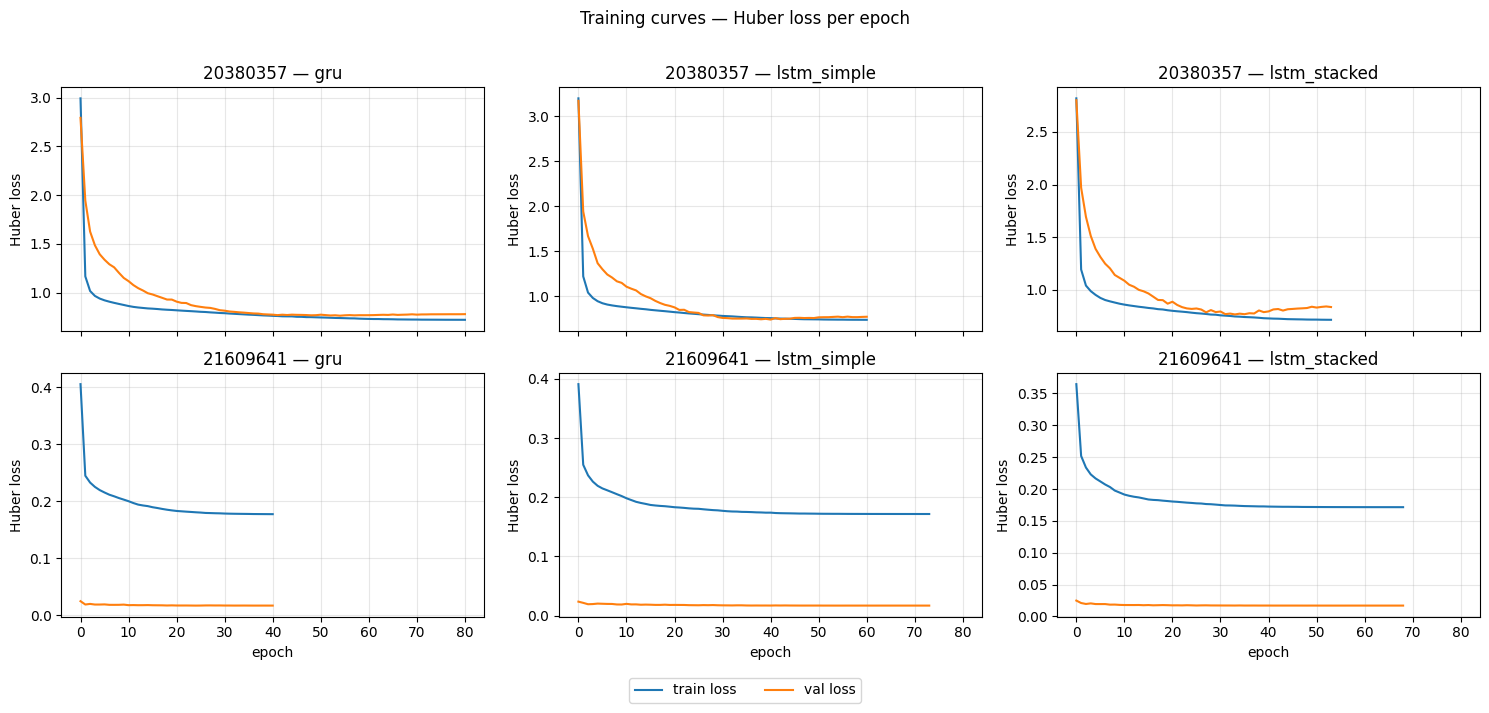

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
fig.suptitle("Training curves — Huber loss per epoch", fontsize=12)
for r, sid in enumerate(stations):
    for c, model_name in enumerate(["gru", "lstm_simple", "lstm_stacked"]):
        h = histories[(sid, model_name)]
        ax = axes[r, c]
        ax.plot(h["loss"], color="C0", label="train loss")
        ax.plot(h["val_loss"], color="C1", label="val loss")
        ax.set_title(f"{sid} — {model_name}")
        ax.set_ylabel("Huber loss")
        ax.grid(alpha=0.3)
        if r == 1:
            ax.set_xlabel("epoch")
fig.legend(["train loss", "val loss"], loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## Hyperparameter Sensitivity: Input Sequence Length

Han & Morrison (2022) Fig. 7a sweeps input lag time and reports the optimum at L=6 on a similarly-sized basin. We adopted L=6 for our main experiments. The ACF analysis on station 21609641 (cell 9) showed daily seasonality, raising the question of whether L=24 would capture that cycle better than L=6.

To answer this, we sweep L ∈ {6, 12, 18, 24} on the GRU at station 21609641 — the well-calibrated station where the model has measurable predictive skill (val MAE ≈ 0.04 cms vs. NWM's ~1.7 cms). The from-paper value of 32 GRU units, batch=128, Adam lr=1e-3, and Huber loss are held fixed; only L varies. Held-out test MAE at lead=1 hour is the comparison metric.

Lag-time sweep: GRU @ station 21609641
L ∈ [6, 12, 18, 24], units=32, batch=128

----------------------------------------------------------------------
  L = 6
----------------------------------------------------------------------
  epochs run: 52
  val_mae:    0.0433 cms
  test_mae:   0.5227 cms
----------------------------------------------------------------------
  L = 12
----------------------------------------------------------------------
  epochs run: 44
  val_mae:    0.0475 cms
  test_mae:   0.4952 cms
----------------------------------------------------------------------
  L = 18
----------------------------------------------------------------------
  epochs run: 56
  val_mae:    0.0458 cms
  test_mae:   0.4915 cms
----------------------------------------------------------------------
  L = 24
----------------------------------------------------------------------
  epochs run: 55
  val_mae:    0.0433 cms
  test_mae:   0.5002 cms

lag-time sweep summary (station 21609641, GRU)


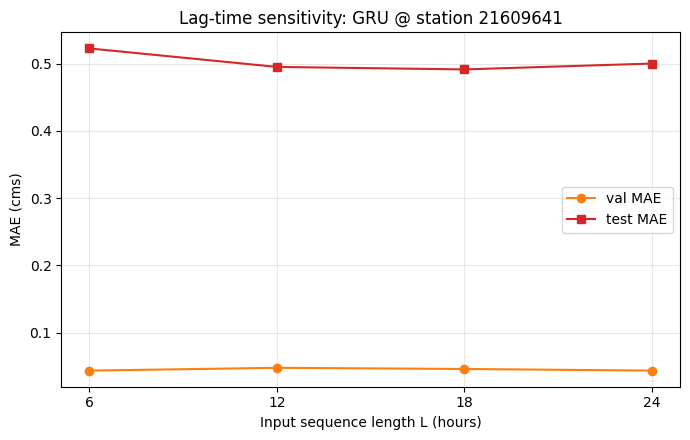

In [11]:
SWEEP_STATION = "21609641"
SWEEP_L_VALUES = [6, 12, 18, 24]
SWEEP_UNITS = 32  # held fixed at the paper's optimum

def build_dataset_for_L(sid, L_val):
    """Rebuild train/valid/test datasets for a single station at a given L.
    Mirrors the logic in cell 13 but parameterized on L. Reuses the train-only
    normalization stats already computed and stored in norm_stats[sid]."""
    splits = {name: pd.read_parquet(DATA_ROOT / sid / f"{name}_{sid}.parquet")
              for name in ("train", "valid", "test")}
    feats = {name: prepare_features(df) for name, df in splits.items()}
    mean, std = norm_stats[sid]

    out = {}
    for name, df in feats.items():
        x = ((df.values - mean) / std).astype(np.float32)
        y_series = df[TARGET_COL].values.astype(np.float32)
        targets = build_seq2seq_targets(y_series, L_val, H)
        out[name] = tf.keras.utils.timeseries_dataset_from_array(
            data=x[:-H],
            targets=targets,
            sequence_length=L_val,
            batch_size=BATCH_SIZE,
            shuffle=(name == "train"),
            seed=42,
        )
    return out

def build_gru_at_L(L_val, n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L_val, n_features)),
        tf.keras.layers.GRU(SWEEP_UNITS),
        tf.keras.layers.Dense(H),
    ])

n_features = len(FEATURE_COLS)
sweep_summary = {}
sweep_histories = {}

print(f"Lag-time sweep: GRU @ station {SWEEP_STATION}")
print(f"L ∈ {SWEEP_L_VALUES}, units={SWEEP_UNITS}, batch={BATCH_SIZE}\n")

for L_val in SWEEP_L_VALUES:
    print(f"{'-'*70}\n  L = {L_val}\n{'-'*70}")
    ds = build_dataset_for_L(SWEEP_STATION, L_val)
    model = build_gru_at_L(L_val, n_features)
    model.compile(
        loss=tf.keras.losses.Huber(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        metrics=["mae"],
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=5),
    ]
    history = model.fit(
        ds["train"],
        validation_data=ds["valid"],
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=0,
    )
    sweep_histories[L_val] = history.history
    _, val_mae  = model.evaluate(ds["valid"], verbose=0)
    _, test_mae = model.evaluate(ds["test"],  verbose=0)
    epochs_run = len(history.history["loss"])
    sweep_summary[L_val] = (val_mae, test_mae, epochs_run)
    print(f"  epochs run: {epochs_run}")
    print(f"  val_mae:    {val_mae:.4f} cms")
    print(f"  test_mae:   {test_mae:.4f} cms")

print(f"\n{'='*70}\nlag-time sweep summary (station {SWEEP_STATION}, GRU)")
print(f"{'='*70}")
print(f"  {'L':>4}  {'val_mae':>10}  {'test_mae':>10}  {'epochs':>8}")
for L_val, (vm, tm, ep) in sweep_summary.items():
    marker = "  <-- baseline" if L_val == 6 else ""
    print(f"  {L_val:>4}  {vm:>10.4f}  {tm:>10.4f}  {ep:>8}{marker}")

# Companion figure mirroring Han & Morrison Fig. 7a layout
fig, ax = plt.subplots(figsize=(7, 4.5))
Ls = list(sweep_summary.keys())
val_maes  = [sweep_summary[L][0] for L in Ls]
test_maes = [sweep_summary[L][1] for L in Ls]
ax.plot(Ls, val_maes,  "o-", label="val MAE",  color="C1")
ax.plot(Ls, test_maes, "s-", label="test MAE", color="C3")
ax.set_xticks(Ls)
ax.set_xlabel("Input sequence length L (hours)")
ax.set_ylabel("MAE (cms)")
ax.set_title(f"Lag-time sensitivity: GRU @ station {SWEEP_STATION}")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Sweep results

The sweep results, run at station 21609641 with all hyperparameters except L held fixed at the values inherited from Han & Morrison (2022):

| L  | val MAE  | test MAE | epochs |
|----|----------|----------|--------|
| 6  | 0.0433   | 0.5227   | 52     |
| 12 | 0.0475   | 0.4952   | 44     |
| 18 | 0.0458   | 0.4915   | 56     |
| 24 | 0.0433   | 0.5002   | 55     |

L=6 — the configuration adopted from the paper and used in the headline experiments above — produces the highest test MAE of the four settings. The minimum test MAE occurs at L=18, with L=12 and L=24 close behind. Total spread across L values is ~0.031 cms on test (~6% relative); val MAE shows a smaller spread (~0.004 cms, ~10% relative) and disagrees with test on the optimum (val-best is L=6 and L=24 tied, test-best is L=18). This val/test disagreement, combined with the small absolute differences, indicates that the ranking among L ∈ {12, 18, 24} should not be over-interpreted from a single training run.

What is more robust is the gradient direction: L=6 is the worst test-MAE configuration. This is consistent with the ACF analysis on station 21609641 (cell 9), which showed daily seasonality that L=6 cannot capture. The paper found L=6 optimal on the Russian River basin; this finding does not contradict the paper but illustrates that the paper's hyperparameter values do not necessarily transfer to a different basin with different hydrologic dynamics. We retain L=6 in the headline experiments above for paper-comparability, but identify L≥12 as a defensible alternative for future work on this basin.

Three scope caveats. First, this sweep was run only at station 21609641 because station 20380357 is signal-poor — its val MAE saturates around 1.0 cms regardless of model configuration due to the basin/gauge drainage-area mismatch documented in §11 of the project notes. Second, the sweep was performed at a single random seed; given the small magnitude of the differences among L ∈ {12, 18, 24}, a multi-seed sweep would be needed to identify a precise optimum within that range. Third, no sweep on number of neurons or batch size was performed — these are inherited from the paper alongside the rest of the hyperparameters, and a per-basin sweep on these is identified as future work alongside Han & Morrison Fig. 7b/c.

## Hydrologic Evaluation

The corrected forecast for each model is reconstructed as `corrected = nwm_q + predicted_error`, since all DL models predict the residual rather than raw runoff. Four metrics are computed per lead time `h = 1..18`:

- **CC** — Pearson correlation
- **NSE** — Nash–Sutcliffe Efficiency
- **PBIAS** — percent bias (positive = overestimate)
- **RMSE** — in cms

Per station, the evaluation produces:

1. Per-lead-time line plots of all four metrics, comparing raw NWM, persistence, GRU, LSTM simple, and stacked LSTM.
2. A scatter plot of corrected vs. observed at leads 1, 9, and 18 for the best-performing DL model (lowest mean RMSE across leads), with raw NWM points underneath for reference.
3. Two time-series snippets at `lead_h = 1` — one centered on the wettest observed hour, one on the driest — showing observed flow, raw NWM, and the best DL correction.

Persistence is included alongside raw NWM as a sanity check; the two should produce identical metrics, since persistence-of-zero-error is by definition the raw NWM forecast.


station 20380357


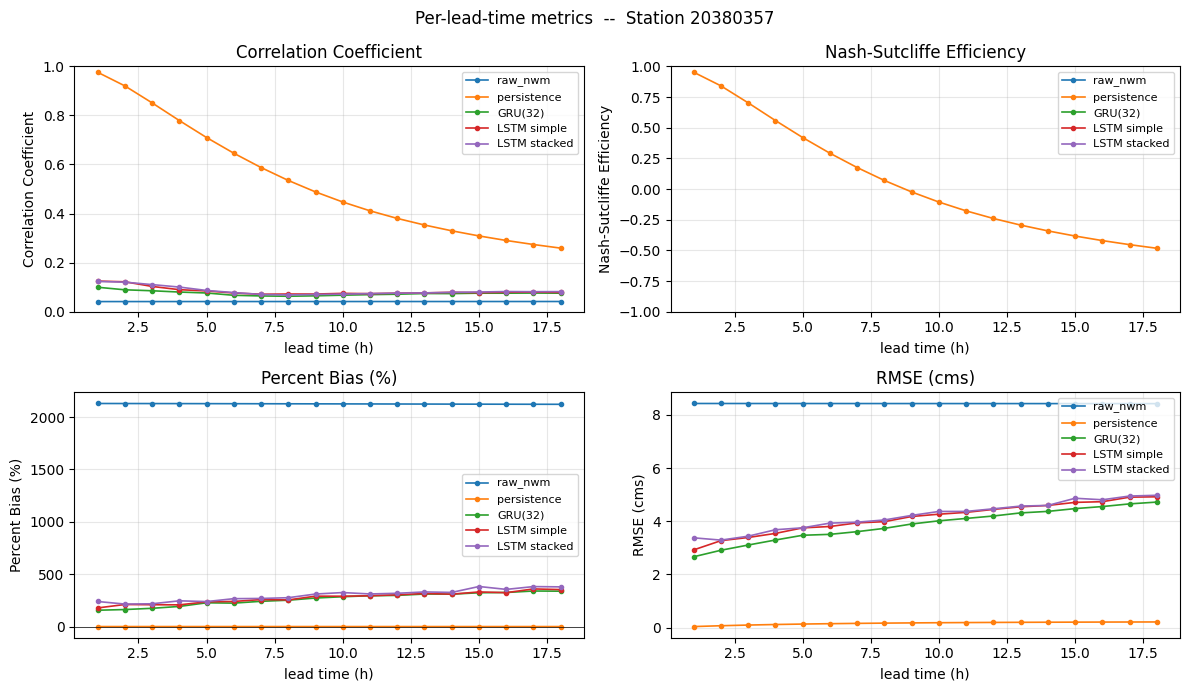

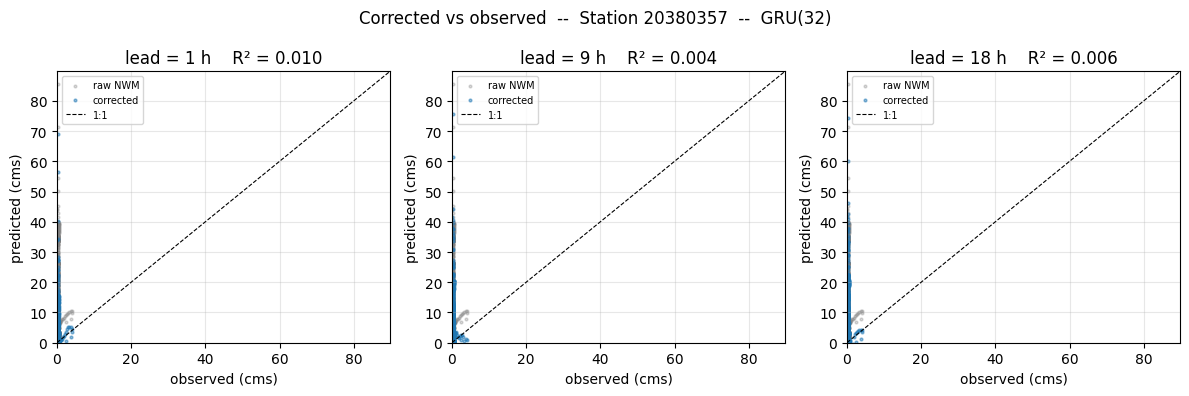

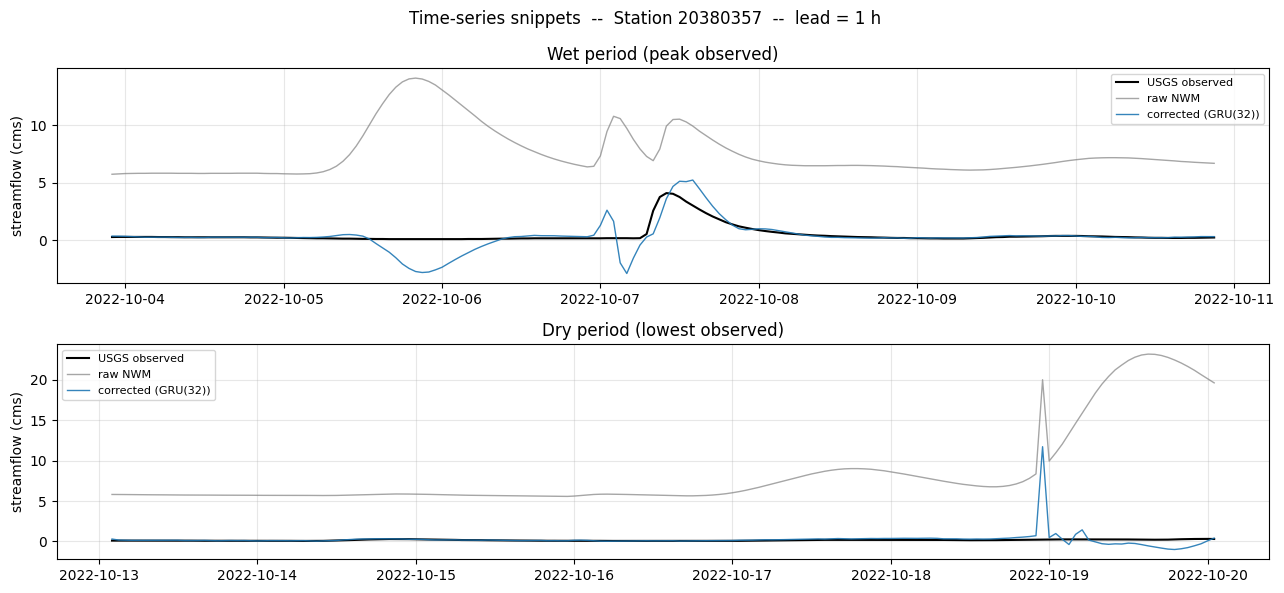


station 21609641


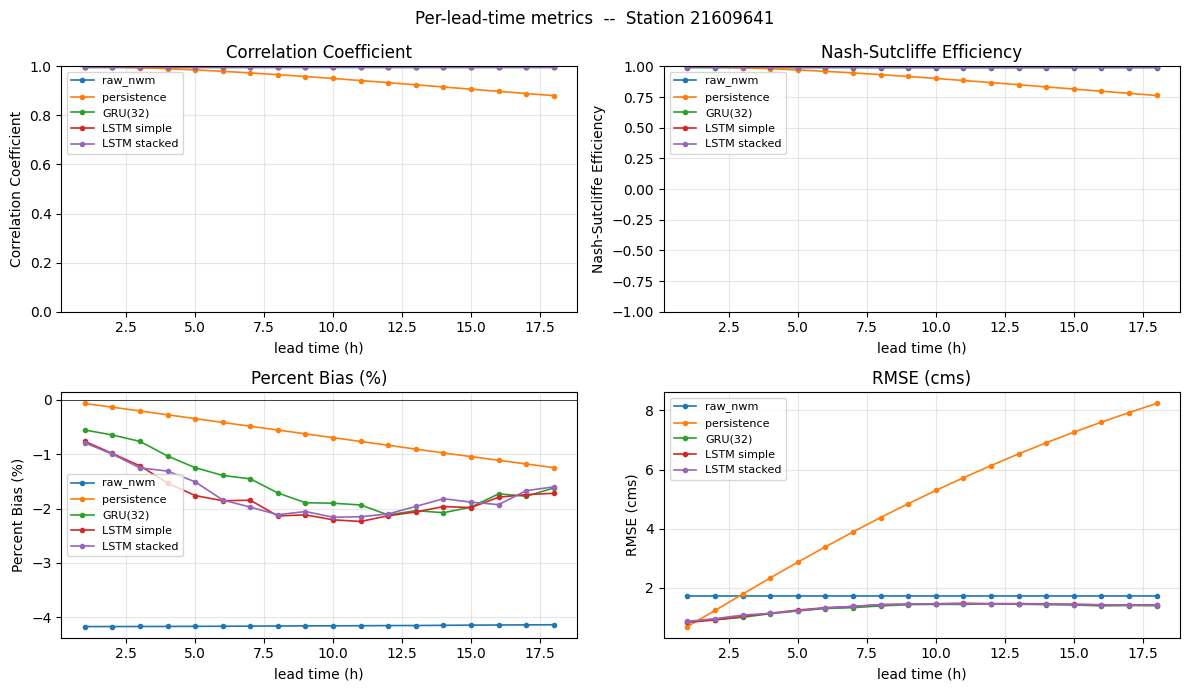

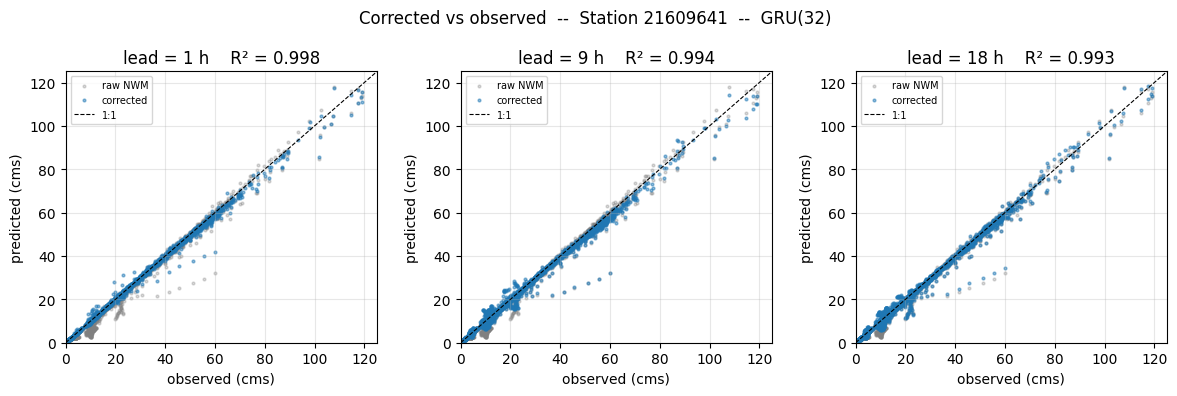

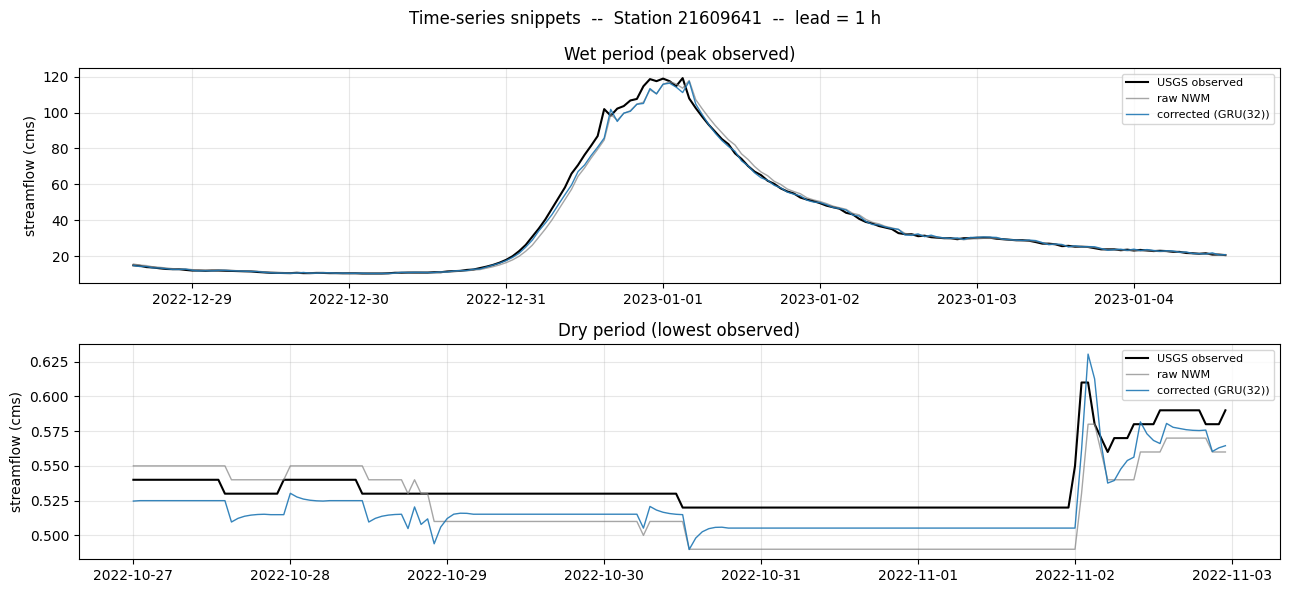


mean metrics across leads 1..18
                           cc          nse        pbias    rmse
station  model                                                 
20380357 gru           0.0750  -503.982208   262.262299  3.8677
         lstm_simple   0.0840  -570.773804   275.486206  4.1254
         lstm_stacked  0.0851  -591.271973   299.069000  4.2052
         persistence   0.5304     0.060400    -0.055600  0.1611
         raw_nwm       0.0415 -2341.146973  2125.811279  8.4297
21609641 gru           0.9972     0.993900    -1.547400  1.3032
         lstm_simple   0.9972     0.993700    -1.779800  1.3239
         lstm_stacked  0.9971     0.993700    -1.727900  1.3252
         persistence   0.9492     0.898800    -0.659400  4.8344
         raw_nwm       0.9953     0.989500    -4.155600  1.7276

  --- lead = 1 h ---
                           cc          nse        pbias    rmse
station  model                                                 
20380357 raw_nwm       0.0413 -2341.176758  2129.

In [17]:
PRETTY = {
    "nwm_raw":      "raw NWM",
    "persistence":  "persistence",
    "gru":          "GRU(32)",
    "lstm_simple":  "LSTM simple",
    "lstm_stacked": "LSTM stacked",
}

def cc(obs, sim):
    o, s = obs - obs.mean(), sim - sim.mean()
    denom = np.sqrt((o**2).sum() * (s**2).sum())
    return (o * s).sum() / denom if denom > 0 else np.nan

def nse(obs, sim):
    denom = ((obs - obs.mean()) ** 2).sum()
    return 1.0 - ((obs - sim) ** 2).sum() / denom if denom > 0 else np.nan

def pbias(obs, sim):
    s = obs.sum()
    return 100.0 * (sim - obs).sum() / s if s != 0 else np.nan

def rmse(obs, sim):
    return float(np.sqrt(((obs - sim) ** 2).mean()))

def evaluate_station(sid):
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")

    test_split = pd.read_parquet(DATA_ROOT / sid / f"test_{sid}.parquet")
    test_feats = prepare_features(test_split)
    nwm_grid = build_seq2seq_targets(test_feats["nwm_q"].values.astype(np.float32), L, H)
    obs_grid = build_seq2seq_targets(test_feats["usgs_q"].values.astype(np.float32), L, H)

    rows = []
    grids = {}

    for name in ["raw_nwm", "persistence", "gru", "lstm_simple", "lstm_stacked"]:
        err_pred = np.load(DATA_ROOT / sid / f"preds_{name}_{sid}.npy")
        corrected = nwm_grid + err_pred
        grids[name] = corrected
        for h in range(H):
            o, s = obs_grid[:, h], corrected[:, h]
            rows.append({"station": sid, "model": name, "lead_h": h + 1,
                        "cc": cc(o, s), "nse": nse(o, s), "pbias": pbias(o, s), "rmse": rmse(o, s)})

    df = pd.DataFrame(rows)
    df.to_csv(DATA_ROOT / sid / f"metrics_{sid}.csv", index=False)
    return df, grids, obs_grid, test_feats

def plot_per_lead_metrics(df, sid):
    metrics = [("cc", "Correlation Coefficient", (0, 1)),
               ("nse", "Nash-Sutcliffe Efficiency", (-1, 1)),
               ("pbias", "Percent Bias (%)", None),
               ("rmse", "RMSE (cms)", None)]
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle(f"Per-lead-time metrics  --  Station {sid}", fontsize=12)

    for ax, (col, title, ylim) in zip(axes.flat, metrics):
        for model in df["model"].unique():
            sub = df[df["model"] == model]
            ax.plot(sub["lead_h"], sub[col], marker="o", ms=3, lw=1.2, label=PRETTY.get(model, model))
        if col == "pbias":
            ax.axhline(0, color="black", lw=0.5)
        ax.set_xlabel("lead time (h)")
        ax.set_ylabel(title)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_scatter(grids, obs_grid, sid, best_name, leads=(1, 9, 18)):
    fig, axes = plt.subplots(1, len(leads), figsize=(4 * len(leads), 4))
    fig.suptitle(f"Corrected vs observed  --  Station {sid}  --  {PRETTY[best_name]}", fontsize=12)

    for ax, lead in zip(axes, leads):
        h = lead - 1
        o = obs_grid[:, h]
        nwm = grids["raw_nwm"][:, h]
        sim = grids[best_name][:, h]
        lim = max(o.max(), nwm.max(), sim.max()) * 1.05

        ax.scatter(o, nwm, s=4, alpha=0.3, color="gray", label="raw NWM")
        ax.scatter(o, sim, s=4, alpha=0.5, color="C0", label="corrected")
        ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("observed (cms)")
        ax.set_ylabel("predicted (cms)")
        ax.set_title(f"lead = {lead} h    R² = {cc(o, sim)**2:.3f}")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_timeseries_snippets(grids, obs_grid, test_feats, sid, best_name):
    n_windows = obs_grid.shape[0]
    valid_times = test_feats.index[L : L + n_windows]
    o_lead1 = obs_grid[:, 0]
    nwm_lead1 = grids["raw_nwm"][:, 0]
    sim_lead1 = grids[best_name][:, 0]

    span = 24 * 7
    wet_center = int(np.argmax(o_lead1))
    dry_center = int(np.argmin(o_lead1))

    fig, axes = plt.subplots(2, 1, figsize=(13, 6))
    fig.suptitle(f"Time-series snippets  --  Station {sid}  --  lead = 1 h", fontsize=12)

    for ax, center, label in [(axes[0], wet_center, "Wet period (peak observed)"),
                              (axes[1], dry_center, "Dry period (lowest observed)")]:
        lo = max(0, center - span // 2)
        hi = min(n_windows, center + span // 2)
        idx = slice(lo, hi)
        ax.plot(valid_times[idx], o_lead1[idx], "k", lw=1.5, label="USGS observed")
        ax.plot(valid_times[idx], nwm_lead1[idx], color="gray", lw=1, alpha=0.7, label="raw NWM")
        ax.plot(valid_times[idx], sim_lead1[idx], color="C0", lw=1, alpha=0.9,
                label=f"corrected ({PRETTY[best_name]})")
        ax.set_ylabel("streamflow (cms)")
        ax.set_title(label)
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

parts = []
for sid in stations:
    df_s, grids, obs_grid, test_feats = evaluate_station(sid)
    parts.append(df_s)

    # best DL model = lowest mean RMSE across leads
    best = min(
        ["gru", "lstm_simple", "lstm_stacked"],
        key=lambda n: np.mean([rmse(obs_grid[:, h], grids[n][:, h]) for h in range(H)]),
    )

    plot_per_lead_metrics(df_s, sid)
    plot_scatter(grids, obs_grid, sid, best)
    plot_timeseries_snippets(grids, obs_grid, test_feats, sid, best)

df_all = pd.concat(parts, ignore_index=True)

print(f"\n{'='*70}\nmean metrics across leads 1..18\n{'='*70}")
print(df_all.groupby(["station", "model"])[["cc", "nse", "pbias", "rmse"]].mean().round(4).to_string())

for lead in (1, 18):
    print(f"\n  --- lead = {lead} h ---")
    print(df_all[df_all["lead_h"] == lead]
          .set_index(["station", "model"])[["cc", "nse", "pbias", "rmse"]]
          .round(4).to_string())

## Prediction vs. Actual Grid — All Models, Lead = 1 h

The literal version of the M3 prediction-vs-actual deliverable. Six panels: two stations × three architectures, all at lead = 1 h. Each panel overlays raw NWM (gray) and the post-processed corrected forecast (blue) against observed runoff, with R² annotated for the corrected forecast against observation. The 1:1 line marks perfect prediction.

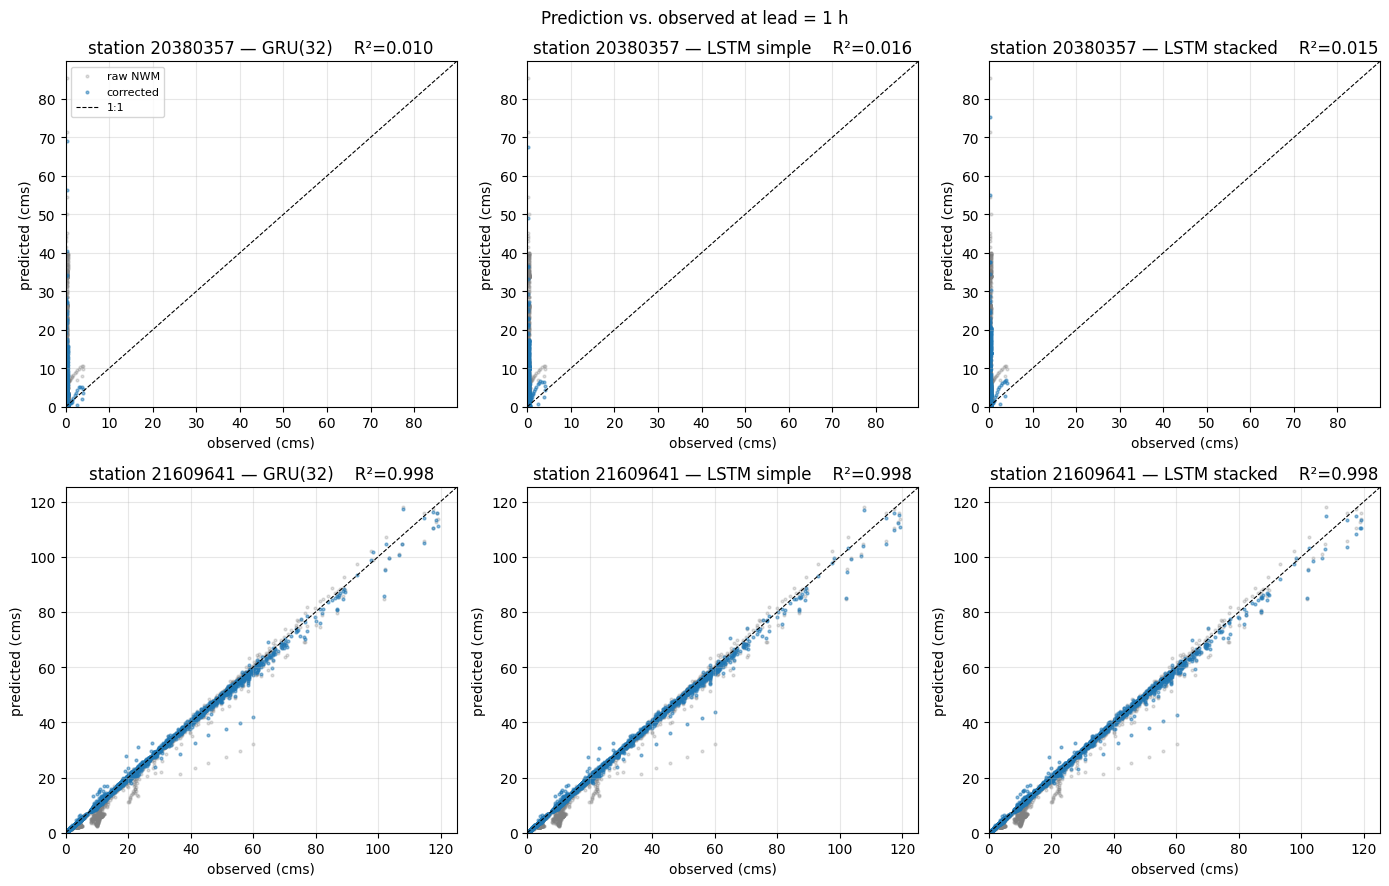

In [13]:
# Prediction-vs-actual at lead = 1 h, 2 stations × 3 architectures.
# Loads predictions from disk so this cell can run without re-running training.
PRETTY_MODELS = {"gru": "GRU(32)", "lstm_simple": "LSTM simple", "lstm_stacked": "LSTM stacked"}
arch_order = ["gru", "lstm_simple", "lstm_stacked"]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Prediction vs. observed at lead = 1 h", fontsize=12)

for r, sid in enumerate(stations):
    test_split = pd.read_parquet(DATA_ROOT / sid / f"test_{sid}.parquet")
    test_feats = prepare_features(test_split)
    nwm_grid = build_seq2seq_targets(test_feats["nwm_q"].values.astype(np.float32), L, H)
    obs_grid = build_seq2seq_targets(test_feats["usgs_q"].values.astype(np.float32), L, H)
    o = obs_grid[:, 0]
    nwm = nwm_grid[:, 0]

    for c, arch in enumerate(arch_order):
        err_pred = np.load(DATA_ROOT / sid / f"preds_{arch}_{sid}.npy")
        sim = (nwm_grid + err_pred)[:, 0]
        ax = axes[r, c]
        lim = max(o.max(), nwm.max(), sim.max()) * 1.05

        ax.scatter(o, nwm, s=4, alpha=0.25, color="gray", label="raw NWM")
        ax.scatter(o, sim, s=4, alpha=0.5,  color="C0",   label="corrected")
        ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_xlabel("observed (cms)")
        ax.set_ylabel("predicted (cms)")
        r2 = np.corrcoef(o, sim)[0, 1] ** 2 if np.isfinite(sim).all() else np.nan
        ax.set_title(f"station {sid} — {PRETTY_MODELS[arch]}    R²={r2:.3f}")
        ax.grid(True, alpha=0.3)
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()